# Project 1: Text Classification

## INSTALL


In [95]:
!pip install -q pythainlp
!pip install -q gensim

## IMPORT

In [97]:
import pandas as pd
import numpy as np
import re

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from pythainlp.tokenize import word_tokenize
from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import seaborn as sns


In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [4]:
df = pd.read_csv("Depression_Dataset.csv")

In [5]:
print("Shape:", df.shape)
display(df.head())

Shape: (33019, 2)


,text,label
0,เพราะปกติถ้ามาวัดที่โรงพยาบาลจะสูงถึงทุกครั้ง,1
1,เรากำลังจะกลับไปในจุดที่เรามีความสุขที่ได้ทำแล...,1
2,บันทึกปีศาจจิตป่วยความเสียใจที่บาดลึก,1
3,เช้าแล้วก็ยังเหมือนเดิม,1
4,ยังคงด่าทอเราได้และข่มขู่ให้เราปล่อย,1


## DATA_PREPARATION

### ตรวจสอบโครงสร้างข้อมูล

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33019 entries, 0 to 33018
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    33019 non-null  object
 1   label   33019 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 516.1+ KB


In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
text     0
label    0
dtype: int64


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 271


In [9]:
print("Unique labels:", df["label"].unique())
print("\nLabel distribution:")
print(df["label"].value_counts())

Unique labels: [1 0]

Label distribution:
label
1    16716
0    16303
Name: count, dtype: int64


In [10]:
empty_text = df["text"].isna().sum() #check empty text

print("Empty text:", empty_text)

Empty text: 0


In [11]:
empty_string = (df["text"].astype(str).str.strip() == "").sum() #check empty String

print("Empty string:", empty_string)

Empty string: 0


### จัดการ Duplicate rows

In [12]:
duplicates = df[df["text"].duplicated(keep=False)].sort_values(by="text")

display(duplicates[["text", "label"]])

,text,label
24053,กดคอร์ดวนไปสามรอบตามโน้ตเพลงนั่นแหละส่วนรอบที่...,0
14434,กดคอร์ดวนไปสามรอบตามโน้ตเพลงนั่นแหละส่วนรอบที่...,0
23298,กบไม่เคยคุยกับนวลเป็นกิจจะลักษณะเลยได้แต่มองดู...,0
13398,กบไม่เคยคุยกับนวลเป็นกิจจะลักษณะเลยได้แต่มองดู...,0
10921,กรีดข้อมือ,1
...,...,...
13141,ไม่ได้,0
20919,ไม่ได้,0
16395,ไม่ไหว,0
11726,ไม่ไหว,1


In [13]:
df = df.drop_duplicates(subset=["text", "label"])

In [14]:
df = df.reset_index(drop=True)

เจอ conflict คือ text เหมือน label ต่าง
แก้ด้วยการลบทิ้งทั้งสอง row ที่เกิด conflict

In [15]:
conflicting = (
    df.groupby("text")["label"]
      .nunique()
)

conflicting_texts = conflicting[conflicting > 1].index

conflicting_df = df[
    df["text"].isin(conflicting_texts)
].sort_values("text")

display(conflicting_df[["text", "label"]])

,text,label
12956,ขอบคุณ,0
25658,ขอบคุณ,1
28805,ขอบคุณค่ะ,0
26536,ขอบคุณค่ะ,1
16152,ขอบคุณนะ,0
...,...,...
9693,ไม่เป็นไรนะ,1
15830,ไม่เอาแล้ว,0
12217,ไม่เอาแล้ว,1
4172,ไม่ไหว,1


In [16]:
df = df[~df["text"].isin(conflicting_texts)].copy()

df = df.reset_index(drop=True)

In [17]:
print("Remaining rows:", len(df))

conflicting_check = (
    df.groupby("text")["label"]
      .nunique()
)

print(
    "Remaining conflicting texts:",
    (conflicting_check > 1).sum()
)

Remaining rows: 32676
Remaining conflicting texts: 0


In [18]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate texts:", df["text"].duplicated().sum())

Duplicate rows: 0
Duplicate texts: 0


### Clean Text

In [19]:
def clean_text(text):
    text = str(text)

    # ลบ URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # ลบ whitespace ที่เกิน
    text = re.sub(r'\s+', ' ', text)

    # ตัดช่องว่างด้านหน้า/หลัง
    text = text.strip()

    return text

In [20]:
df["clean_text"] = df["text"].apply(clean_text)

In [21]:
display(df[["text", "clean_text", "label"]].head(10))

,text,clean_text,label
0,เพราะปกติถ้ามาวัดที่โรงพยาบาลจะสูงถึงทุกครั้ง,เพราะปกติถ้ามาวัดที่โรงพยาบาลจะสูงถึงทุกครั้ง,1
1,เรากำลังจะกลับไปในจุดที่เรามีความสุขที่ได้ทำแล...,เรากำลังจะกลับไปในจุดที่เรามีความสุขที่ได้ทำแล...,1
2,บันทึกปีศาจจิตป่วยความเสียใจที่บาดลึก,บันทึกปีศาจจิตป่วยความเสียใจที่บาดลึก,1
3,เช้าแล้วก็ยังเหมือนเดิม,เช้าแล้วก็ยังเหมือนเดิม,1
4,ยังคงด่าทอเราได้และข่มขู่ให้เราปล่อย,ยังคงด่าทอเราได้และข่มขู่ให้เราปล่อย,1
5,เมื่อราวๆต้นปีล่ะมั้งที่เราได้ฟังเพลงของในอัลบ...,เมื่อราวๆต้นปีล่ะมั้งที่เราได้ฟังเพลงของในอัลบ...,1
6,ด้วยเหตุผลนี้หมอเลยสั่งออฟยาตัวเดิม,ด้วยเหตุผลนี้หมอเลยสั่งออฟยาตัวเดิม,1
7,แล้วมันไม่ช่วยอะไรเลย,แล้วมันไม่ช่วยอะไรเลย,1
8,เราคลื่นไส้ตลอดเวลาเวียนหัวหวิวๆในวันแรก,เราคลื่นไส้ตลอดเวลาเวียนหัวหวิวๆในวันแรก,1
9,ฉันไม่ชอบความไม่แน่นอน,ฉันไม่ชอบความไม่แน่นอน,1


In [22]:
empty_after_cleaning = (
    df["clean_text"].str.strip() == ""
).sum()

print("Empty texts after cleaning:", empty_after_cleaning) #check empty text

Empty texts after cleaning: 0


In [23]:
print(
    "Duplicate clean texts:",
    df["clean_text"].duplicated().sum()
) #check duplicate text

Duplicate clean texts: 0


### ตรวจ Class Distribution
เป็นการ check imbalance

In [24]:
print("Label distribution:")
print(df["label"].value_counts())

print("\nLabel percentage:")
print(df["label"].value_counts(normalize=True) * 100)

Label distribution:
label
1    16538
0    16138
Name: count, dtype: int64

Label percentage:
label
1    50.61207
0    49.38793
Name: proportion, dtype: float64


### ตรวจความยาวของข้อความ
ไม่ได้ลบ row ไหนออกเพราะ ความยาวของ text ยังอยู่ในเกณฑ์ที่ใช้ได้

In [25]:
df["text_length"] = df["clean_text"].str.len()

print(df["text_length"].describe())

count    32676.000000
mean        68.850043
std         84.041805
min          2.000000
25%         27.000000
50%         46.000000
75%         82.000000
max       2901.000000
Name: text_length, dtype: float64


In [26]:
display(
    df.sort_values("text_length")
      [["clean_text", "label", "text_length"]]
      .head(20)
)

,clean_text,label,text_length
31442,ไง,0,2
11210,ลป,1,2
25736,สี,1,2
15099,คน,0,2
27171,โห,0,2
11136,ฮึบ,1,3
26246,ฉัน,1,3
14111,สอง,0,3
16006,เขา,0,3
2116,สัก,1,3


In [27]:
display(
    df.sort_values("text_length", ascending=False)
      [["clean_text", "label", "text_length"]]
      .head(20)
)

,clean_text,label,text_length
16567,ไม่เกินลงตัวซึ่งเป็นการช่วยเหลือโดยไม่หวังผลตอ...,0,2901
15954,ๆจึงคล้ายกับฝันร้ายที่ไม่อยากให้เกิดขึ้นจริงแล...,0,2682
22654,ยังไม่เช้าอีกเหรอวะคืนนี้หนึ่งคืนนี่มีชั่วโมงเ...,0,2348
15796,ไม่รีบฉันพึมพำกับตัวเองแล้วเดินมาแต่งหน้าเบาๆใ...,0,2317
22812,ผมขอชวนให้ท่านผู้อ่านลองนึกถึงบ้านหลังใหญ่แห่ง...,0,2149
21067,บางครั้งฉันก็นึกสงสัยว่าหัวของฉันคือโรงฉายภาพย...,0,1836
28223,สูบบุหรี่มั้ยป้ะบุหรี่ตัวสุดท้ายของวันถูกจุดขึ...,0,1813
19467,เรื่องเพ้อพกฉันคนนี้คงประสบพบปัญหาหากแต่เพียงฉ...,0,1791
22837,ยินดีต้อนรับการกลับมาพบกันอีกครั้งยินดีต้อนรับ...,0,1604
18513,ความกลัวกลัวที่คิดว่าคุณอาจจะรักใครที่ดีกว่าเร...,0,1406


## Train/validation/Test Split
  70/15/15

In [28]:
df = df[["text", "clean_text", "label"]].copy()

In [29]:
X = df["clean_text"]
y = df["label"]

# Train 70%, Temp 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Validation 15%, Test 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [30]:
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\nTrain distribution:")
print(y_train.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Train: 22873
Validation: 4901
Test: 4902

Train distribution:
label
1    11576
0    11297
Name: count, dtype: int64

Validation distribution:
label
1    2481
0    2420
Name: count, dtype: int64

Test distribution:
label
1    2481
0    2421
Name: count, dtype: int64


## save เป็น csv

In [31]:
train_df = df.loc[X_train.index, ["text", "clean_text", "label"]].copy()
val_df = df.loc[X_val.index, ["text", "clean_text", "label"]].copy()
test_df = df.loc[X_test.index, ["text", "clean_text", "label"]].copy()

# Reset index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [32]:
print("Train:")
display(train_df.head())

print("\nValidation:")
display(val_df.head())

print("\nTest:")
display(test_df.head())

Train:


,text,clean_text,label
0,จะแบบไหนก็แย่ทั้งนั้น,จะแบบไหนก็แย่ทั้งนั้น,1
1,เขาอยากจะทิ้งกายกลับไปพักผ่อนที่บ้านมากกว่าแทน...,เขาอยากจะทิ้งกายกลับไปพักผ่อนที่บ้านมากกว่าแทน...,0
2,เธอชอบกินมายองเนสสิ่งที่เธอชอบกิน,เธอชอบกินมายองเนสสิ่งที่เธอชอบกิน,0
3,นั่นจะส่งผลให้อาการซึมเศร้าของฉันกลับมารุนแรงอ...,นั่นจะส่งผลให้อาการซึมเศร้าของฉันกลับมารุนแรงอ...,1
4,โดยเฉพาะพ่อแม่,โดยเฉพาะพ่อแม่,1



Validation:


,text,clean_text,label
0,มันทำให้ใจฉันแทบสลายแต่แปลกที่มันกลับไม่มีน้ำต...,มันทำให้ใจฉันแทบสลายแต่แปลกที่มันกลับไม่มีน้ำต...,1
1,พอตกกลางคืนก็หมดแรงนอนหลับไปได้โดยง่ายด้วยความ...,พอตกกลางคืนก็หมดแรงนอนหลับไปได้โดยง่ายด้วยความ...,0
2,เหลือเม็ดเดียว,เหลือเม็ดเดียว,1
3,ไม่มีใครจะเชื่อฟัก,ไม่มีใครจะเชื่อฟัก,0
4,มันก็มีหนังสือธรรมะเล็กๆไม่กี่เล่มที่เราได้เปิ...,มันก็มีหนังสือธรรมะเล็กๆไม่กี่เล่มที่เราได้เปิ...,0



Test:


,text,clean_text,label
0,เราคิดว่าเราชนะคดี,เราคิดว่าเราชนะคดี,0
1,สบายๆแต่ถ้าความต้องการของเราไม่ได้รับการเติมเต็ม,สบายๆแต่ถ้าความต้องการของเราไม่ได้รับการเติมเต็ม,0
2,นางเลยอาสาพาไปเจาะแบบดีๆเพราะไม่อยากให้เราเจ็บ...,นางเลยอาสาพาไปเจาะแบบดีๆเพราะไม่อยากให้เราเจ็บ...,1
3,เขาเดินและมุ่งมั่นที่จะเป็นไปก็เท่านั้นเอง,เขาเดินและมุ่งมั่นที่จะเป็นไปก็เท่านั้นเอง,0
4,กบบันทึกเรื่ิงราวความสุขของกบลงในสมุดบันทึกลาย...,กบบันทึกเรื่ิงราวความสุขของกบลงในสมุดบันทึกลาย...,0


In [33]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("Train:")
print(train_df["label"].value_counts())

print("\nValidation:")
print(val_df["label"].value_counts())

print("\nTest:")
print(test_df["label"].value_counts())

Train: (22873, 3)
Validation: (4901, 3)
Test: (4902, 3)
Train:
label
1    11576
0    11297
Name: count, dtype: int64

Validation:
label
1    2481
0    2420
Name: count, dtype: int64

Test:
label
1    2481
0    2421
Name: count, dtype: int64


In [34]:
train_df.to_csv(
    "NLP-train.csv",
    index=False,
    encoding="utf-8-sig"
)

val_df.to_csv(
    "NLP-validation.csv",
    index=False,
    encoding="utf-8-sig"
)

test_df.to_csv(
    "NLP-test.csv",
    index=False,
    encoding="utf-8-sig"
)

## IMPORT TRAIN,TEST,VALIDATION

In [35]:
train_df = pd.read_csv("NLP-train.csv")
val_df = pd.read_csv("NLP-validation.csv")
test_df = pd.read_csv("NLP-test.csv")

## 1. Word2Vec + BiLSTM

### 1.1 Thai Tokenization

In [36]:
def thai_tokenize(text):
    return word_tokenize(
        str(text),
        engine="newmm",
        keep_whitespace=False
    )

In [37]:
BIMD_train_tokens = train_df["clean_text"].apply(thai_tokenize).tolist()
BIMD_val_tokens = val_df["clean_text"].apply(thai_tokenize).tolist()
BIMD_test_tokens = test_df["clean_text"].apply(thai_tokenize).tolist()

### 1.2 check length

In [38]:
BIMD_token_lengths = np.array([len(tokens) for tokens in BIMD_train_tokens])

print("Min:",BIMD_token_lengths.min())
print("Max:", BIMD_token_lengths.max())
print("Mean:", BIMD_token_lengths.mean())
print("Median:", np.median(BIMD_token_lengths))
print("95th percentile:", np.percentile(BIMD_token_lengths, 95))
print("99th percentile:", np.percentile(BIMD_token_lengths, 99))

Min: 1
Max: 572
Mean: 16.59222664276658
Median: 11.0
95th percentile: 46.0
99th percentile: 89.0


### 1.3 Word2Vec

In [39]:
w2v_model = Word2Vec(
    sentences=BIMD_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=10,
    seed=42
)

In [40]:
print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 9200


In [41]:
word = "เศร้า"

if word in w2v_model.wv:
    vector = w2v_model.wv[word]

    print("Word:", word)
    print("Vector shape:", vector.shape)
    print("Vector:")
    print(vector)
else:
    print(f"ไม่พบคำว่า '{word}' ใน vocabulary")

Word: เศร้า
Vector shape: (100,)
Vector:
[ 3.49656880e-01  3.63415867e-01 -1.24403695e-02 -2.14443624e-01
 -1.72799692e-01 -2.67966837e-01 -6.29834682e-02  1.21337876e-01
  1.08215772e-01 -1.23970576e-01 -4.56412494e-01  2.26218328e-01
  2.15812232e-02  2.36950010e-01  2.55419791e-01 -2.68933594e-01
 -2.17949520e-04 -9.98293579e-01  6.52119964e-02 -2.16651514e-01
  1.42057613e-01  5.23419082e-01  4.21465665e-01 -3.94461364e-01
  4.78498191e-01  4.13813535e-03 -3.53765815e-01 -1.51406735e-01
 -3.11565697e-01  5.86389959e-01 -1.82913199e-01 -8.07357058e-02
  8.18335935e-02 -6.81113303e-02  1.61616340e-01 -3.41591507e-01
  4.26365947e-03 -3.10643226e-01  9.70417261e-01 -1.50680348e-01
  1.31569326e-01 -9.90134776e-02  1.13929719e-01 -4.04845655e-01
  3.53916106e-03 -1.30664125e-01  5.13841987e-01  1.93377826e-02
  8.28094125e-01 -1.88221395e-01  6.07425869e-02 -8.74577224e-01
 -5.02230898e-02 -1.21393874e-01  3.42277765e-01 -4.86709714e-01
 -4.18173373e-01  6.14602864e-01 -3.05891987e-02 

In [42]:
word = "เศร้า"

if word in w2v_model.wv:
    similar_words = w2v_model.wv.most_similar(
        word,
        topn=10
    )

    for w, score in similar_words:
        print(f"{w:15s} {score:.4f}")

ต้าน            0.7063
แทบตาย          0.7041
เหงา            0.6900
ซึ้งใจ          0.6777
แสดงว่า         0.6737
มากยิ่งขึ้น     0.6722
เป็นพิเศษ       0.6676
น่าดู           0.6647
ทั้งกายและใจ    0.6620
เดี๋ยวนี้       0.6602


### 1.4 Vocabulary Mapping

In [43]:
BIMD_PAD_IDX = 0
BIMD_UNK_IDX = 1

BIMD_word_to_index = {
    word: idx + 2
    for idx, word in enumerate(
        w2v_model.wv.index_to_key
    )
}

BIMD_vocab_size = len(BIMD_word_to_index) + 2

print("Vocabulary size:", BIMD_vocab_size)
print("PAD index:", BIMD_PAD_IDX)
print("UNK index:", BIMD_UNK_IDX)

Vocabulary size: 9202
PAD index: 0
UNK index: 1


In [44]:
def tokens_to_sequence(tokens, word_to_index): # แปลงคำ → index
    return [
        word_to_index.get(word, BIMD_UNK_IDX)
        for word in tokens
    ]

In [45]:
BIMD_sample_tokens = BIMD_train_tokens[0]

sample_sequence = tokens_to_sequence(
    BIMD_sample_tokens,
    BIMD_word_to_index
)

print("Tokens:")
print(BIMD_sample_tokens)

print("\nSequence:")
print(sample_sequence)

Tokens:
['จะ', 'แบบ', 'ไหน', 'ก็', 'แย่', 'ทั้งนั้น']

Sequence:
[6, 66, 96, 5, 196, 769]


### 1.5 Padding

In [46]:
MAX_LEN = 100

In [47]:
BIMD_train_sequences = [
    tokens_to_sequence(tokens, BIMD_word_to_index)
    for tokens in BIMD_train_tokens
]

In [48]:
def make_padded_sequences(tokens_list):
    sequences = [tokens_to_sequence(tokens, BIMD_word_to_index) for tokens in tokens_list]
    return pad_sequences(
        sequences,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post",
        value=BIMD_PAD_IDX
    )

In [49]:
BIMD_X_train = make_padded_sequences(BIMD_train_tokens)

print("Shape:", X_train.shape)

Shape: (22873,)


###1.6 Embedding Matrix

In [50]:
BIMD_embedding_dim = w2v_model.vector_size

BIMD_embedding_matrix = np.zeros(
    (BIMD_vocab_size, BIMD_embedding_dim),
    dtype=np.float32
)

for word, idx in BIMD_word_to_index.items():
    BIMD_embedding_matrix[idx] = w2v_model.wv[word]

print("Embedding matrix shape:")
print(BIMD_embedding_matrix.shape)

Embedding matrix shape:
(9202, 100)


###1.7 Validation/Test

In [51]:
BIMD_X_val = make_padded_sequences(BIMD_val_tokens)
BIMD_X_test = make_padded_sequences(BIMD_test_tokens)

BIMD_y_train = train_df["label"].to_numpy()
BIMD_y_val = val_df["label"].to_numpy()
BIMD_y_test = test_df["label"].to_numpy()

print("Data Preparation Complete:")
print(f"X_train shape: {BIMD_X_train.shape}")
print(f"X_val shape: {BIMD_X_val.shape}")
print(f"X_test shape: {BIMD_X_test.shape}")

Data Preparation Complete:
X_train shape: (22873, 100)
X_val shape: (4901, 100)
X_test shape: (4902, 100)


###1.8 BiLSTM

In [52]:
BI_model = Sequential([
    Embedding(
        input_dim=BIMD_vocab_size,
        output_dim=BIMD_embedding_dim,
        weights=[BIMD_embedding_matrix],
        mask_zero=True,
        trainable=True
    ),

    Bidirectional(LSTM(64)),

    Dropout(0.30),

    Dense(32, activation="relu"),

    Dropout(0.20),

    Dense(1, activation="sigmoid")
])

BI_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

BI_model.build(input_shape=(None, MAX_LEN))
BI_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │       920,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,008,841 (3.85 MB)

 Trainable params: 1,008,841 (3.85 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
BIMD_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.5,
        min_lr=1e-6
    )
]

BIMD_history = BI_model.fit(
    BIMD_X_train,
    BIMD_y_train,
    validation_data=(BIMD_X_val, BIMD_y_val),
    epochs=15,
    batch_size=64,
    callbacks=BIMD_callbacks,
    verbose=1
)

Epoch 1/15
358/358 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.7482 - loss: 0.5052 - val_accuracy: 0.7778 - val_loss: 0.4585 - learning_rate: 0.0010
Epoch 2/15
358/358 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.8054 - loss: 0.4159 - val_accuracy: 0.7819 - val_loss: 0.4452 - learning_rate: 0.0010
Epoch 3/15
358/358 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.8341 - loss: 0.3603 - val_accuracy: 0.7823 - val_loss: 0.4632 - learning_rate: 0.0010
Epoch 4/15
358/358 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.8543 - loss: 0.3174 - val_accuracy: 0.7802 - val_loss: 0.5042 - learning_rate: 0.0010
Epoch 5/15
358/358 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.8830 - loss: 0.2625 - val_accuracy: 0.7809 - val_loss: 0.5459 - learning_rate: 5.0000e-04


(Train loss/Validation loss) & (Train accuracy/Validation accuracy)

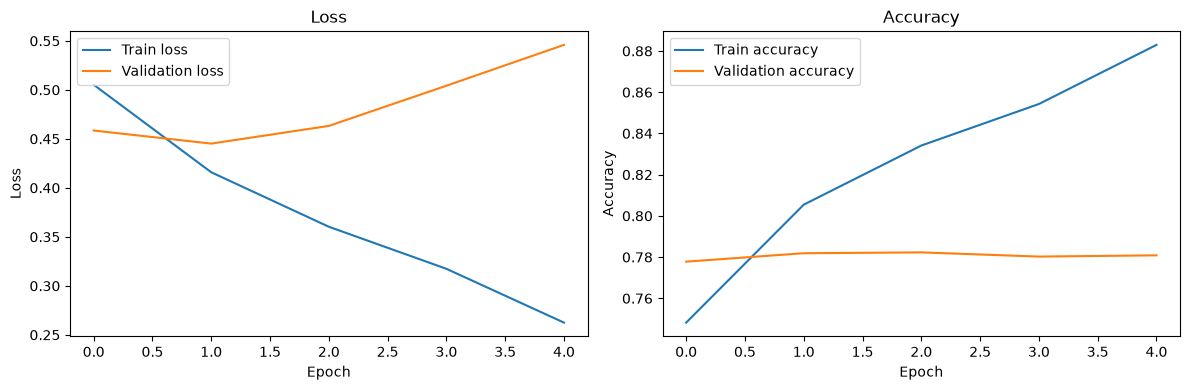

In [54]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(BIMD_history.history["loss"], label="Train loss")
plt.plot(BIMD_history.history["val_loss"], label="Validation loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(BIMD_history.history["accuracy"], label="Train accuracy")
plt.plot(BIMD_history.history["val_accuracy"], label="Validation accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

###1.9 Evaluation

In [55]:
BIMD_test_prob = BI_model.predict(BIMD_X_test)
BIMD_test_pred = (BIMD_test_prob >= 0.5).astype(int).ravel()

print("Test accuracy:", accuracy_score(BIMD_y_test, BIMD_test_pred))

print("\nClassification report:")
print(classification_report(
    BIMD_y_test,
    BIMD_test_pred,
    digits=4
))

154/154 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
Test accuracy: 0.7839657282741738

Classification report:
              precision    recall  f1-score   support

           0     0.8299    0.7076    0.7639      2421
           1     0.7505    0.8585    0.8009      2481

    accuracy                         0.7840      4902
   macro avg     0.7902    0.7830    0.7824      4902
weighted avg     0.7897    0.7840    0.7826      4902



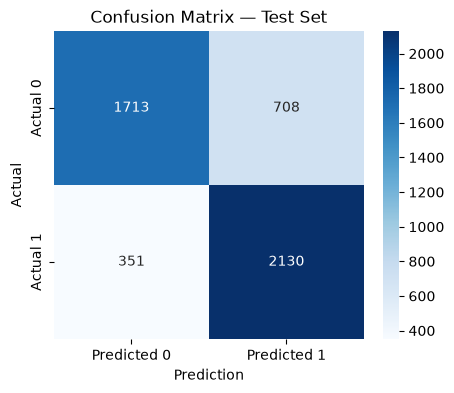

In [56]:

BIMD_cm = confusion_matrix(BIMD_y_test, BIMD_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    BIMD_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.show()

## 2. Logistic Regression + Bag of Word

### 2.1 set up

In [57]:
LR_RANDOM_STATE = 42
LR_C_GRID = [0.1, 0.3, 1, 3, 10]


def LR_identity(x):  # บอก vectorizer ว่ารับ token list มาแล้ว ไม่ต้องตัดคำซ้ำ
    return x


# ใช้ thai_tokenize และ train_df / val_df / test_df ของส่วนกลาง
LR_train_tokens = train_df["clean_text"].apply(thai_tokenize).tolist()
LR_val_tokens = val_df["clean_text"].apply(thai_tokenize).tolist()
LR_test_tokens = test_df["clean_text"].apply(thai_tokenize).tolist()

LR_y_train = train_df["label"].to_numpy()
LR_y_val = val_df["label"].to_numpy()
LR_y_test = test_df["label"].to_numpy()

# train + validation รวมกัน ใช้ตอน train model สุดท้าย
LR_full_tokens = LR_train_tokens + LR_val_tokens
LR_y_full = np.concatenate([LR_y_train, LR_y_val])

print("train:", len(LR_train_tokens))
print("val:  ", len(LR_val_tokens))
print("test: ", len(LR_test_tokens))


train: 22873
val:   4901
test:  4902


### 2.2 check length

In [58]:
LR_token_lengths = np.array([len(tokens) for tokens in LR_train_tokens])

print("Empty documents:", (LR_token_lengths == 0).sum())
print("Min:", LR_token_lengths.min())
print("Max:", LR_token_lengths.max())
print("Mean:", round(LR_token_lengths.mean(), 2))
print("Median:", np.median(LR_token_lengths))
print("95th percentile:", np.percentile(LR_token_lengths, 95))
print("99th percentile:", np.percentile(LR_token_lengths, 99))


Empty documents: 0
Min: 1
Max: 572
Mean: 16.59
Median: 11.0
95th percentile: 46.0
99th percentile: 89.0


### 2.3 Logistic Regression Functions

In [59]:
def LR_train_logreg(X, y, C):
    model = LogisticRegression(
        C=C,
        max_iter=3000,
        solver="liblinear",
        random_state=LR_RANDOM_STATE
    )
    model.fit(X, y)
    return model


def LR_evaluate(model, X, y):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
        "roc_auc": roc_auc_score(y, proba)
    }


# จูนค่า C ทีละค่า
def LR_tune_C(X_train, y_train, X_val, y_val):
    rows = []
    for C in LR_C_GRID:
        model = LR_train_logreg(X_train, y_train, C)
        rows.append({"C": C, **LR_evaluate(model, X_val, y_val)})
    return pd.DataFrame(rows)


def LR_plot_tune(tune_df, title):
    plt.figure(figsize=(6, 3.5))
    plt.semilogx(tune_df["C"], tune_df["accuracy"], "o-", label="accuracy")
    plt.semilogx(tune_df["C"], tune_df["f1"], "s--", label="f1")
    plt.xlabel("C")
    plt.ylabel("score")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def LR_show_result(model, X, y, title):
    pred = model.predict(X)

    print("Classification report:")
    print(classification_report(y, pred, digits=4))

    cm = confusion_matrix(y, pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )
    plt.title(title)
    plt.show()


def LR_top_words(vectorizer, model, k=15):
    names = np.array(vectorizer.get_feature_names_out())
    coefs = model.coef_[0]
    order = np.argsort(coefs)
    return names[order[-k:]][::-1], names[order[:k]]


### 2.4 CountVectorizer parameters

In [60]:
def LR_make_bow(ngram_range, min_df):
    return CountVectorizer(
        tokenizer=LR_identity,
        preprocessor=LR_identity,
        lowercase=False,
        token_pattern=None,
        ngram_range=ngram_range,
        min_df=min_df
    )


### 2.5 Hyperparameter Tuning

In [61]:
LR_NGRAM_OPTIONS = [(1, 1), (1, 2), (1, 3)]
LR_MIN_DF_OPTIONS = [1, 2, 5]

LR_rows = []

for LR_ngram in LR_NGRAM_OPTIONS:
    for LR_min_df in LR_MIN_DF_OPTIONS:
        LR_vec = LR_make_bow(LR_ngram, LR_min_df)
        LR_X_tr = LR_vec.fit_transform(LR_train_tokens)
        LR_X_va = LR_vec.transform(LR_val_tokens)

        LR_m = LR_train_logreg(LR_X_tr, LR_y_train, C=1)
        LR_scores = LR_evaluate(LR_m, LR_X_va, LR_y_val)

        LR_rows.append({
            "ngram_range": LR_ngram,
            "min_df": LR_min_df,
            "n_features": LR_X_tr.shape[1],
            "accuracy": LR_scores["accuracy"],
            "f1": LR_scores["f1"]
        })

LR_bow_grid = pd.DataFrame(LR_rows).sort_values("accuracy", ascending=False)

display(LR_bow_grid.round(4).reset_index(drop=True))


,ngram_range,min_df,n_features,accuracy,f1
0,"(1, 3)",1,447768,0.7827,0.7927
1,"(1, 3)",2,70993,0.7821,0.7901
2,"(1, 2)",1,170411,0.7815,0.7909
3,"(1, 2)",2,47578,0.7780,0.7862
4,"(1, 1)",1,14537,0.7770,0.7881
5,"(1, 2)",5,14947,0.7764,0.7840
6,"(1, 1)",2,9117,0.7760,0.7869
7,"(1, 3)",5,18067,0.7731,0.7818
8,"(1, 1)",5,4860,0.7725,0.7832


In [62]:
LR_TOLERANCE = 0.005

LR_best_acc = LR_bow_grid["accuracy"].max()
LR_candidates = LR_bow_grid[LR_bow_grid["accuracy"] >= LR_best_acc - LR_TOLERANCE]

print(f"accuracy สูงสุด = {LR_best_acc:.4f}")
print(f"ตัวเลือกที่ห่างไม่เกิน {LR_TOLERANCE}:")
display(LR_candidates.round(4).reset_index(drop=True))

LR_chosen = LR_candidates.loc[LR_candidates["n_features"].idxmin()]

LR_NGRAM_RANGE = LR_chosen["ngram_range"]
LR_MIN_DF = int(LR_chosen["min_df"])

print("เลือก ngram_range =", LR_NGRAM_RANGE)
print("เลือก min_df      =", LR_MIN_DF)
print("จำนวนฟีเจอร์      =", int(LR_chosen["n_features"]))


accuracy สูงสุด = 0.7827
ตัวเลือกที่ห่างไม่เกิน 0.005:


,ngram_range,min_df,n_features,accuracy,f1
0,"(1, 3)",1,447768,0.7827,0.7927
1,"(1, 3)",2,70993,0.7821,0.7901
2,"(1, 2)",1,170411,0.7815,0.7909
3,"(1, 2)",2,47578,0.7780,0.7862


เลือก ngram_range = (1, 2)
เลือก min_df      = 2
จำนวนฟีเจอร์      = 47578


In [63]:
LR_bow = LR_make_bow(LR_NGRAM_RANGE, LR_MIN_DF)

LR_A_train = LR_bow.fit_transform(LR_train_tokens)
LR_A_val = LR_bow.transform(LR_val_tokens)

LR_bow_tune = LR_tune_C(LR_A_train, LR_y_train, LR_A_val, LR_y_val)

display(LR_bow_tune.round(4))


,C,accuracy,precision,recall,f1,roc_auc
0,0.1,0.7723,0.7483,0.8291,0.7866,0.8600
1,0.3,0.7843,0.7661,0.8263,0.7950,0.8652
2,1.0,0.7780,0.7670,0.8065,0.7862,0.8629
3,3.0,0.7688,0.7641,0.7860,0.7749,0.8560
4,10.0,0.7586,0.7582,0.7682,0.7632,0.8460


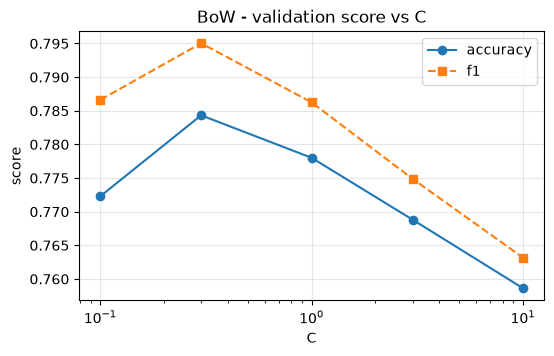

Best C: 0.3


In [64]:
# plot ดูค่าว่า overfit หรือ underfit
LR_plot_tune(LR_bow_tune, "BoW - validation score vs C")

LR_best_C_bow = LR_bow_tune.loc[LR_bow_tune["accuracy"].idxmax(), "C"]

print("Best C:", LR_best_C_bow)


### 2.6 Create Features

In [65]:
LR_bow_final = LR_make_bow(LR_NGRAM_RANGE, LR_MIN_DF)

LR_A_full = LR_bow_final.fit_transform(LR_full_tokens)
LR_A_test = LR_bow_final.transform(LR_test_tokens)

print("Vocabulary size:", len(LR_bow_final.vocabulary_))
print("Train shape:", LR_A_full.shape)
print("Test shape: ", LR_A_test.shape)


Vocabulary size: 55860
Train shape: (27774, 55860)
Test shape:  (4902, 55860)


In [66]:
LR_sample = LR_A_full[0]
LR_names = LR_bow_final.get_feature_names_out()

print("Non-zero features in doc 0:", LR_sample.nnz)
print("Total features:", LR_A_full.shape[1])
print()

for LR_idx in LR_sample.indices[:10]:
    print(f"{LR_names[LR_idx]:20s} {LR_sample[0, LR_idx]}")


Non-zero features in doc 0: 10
Total features: 55860

จะ                   1
แบบ                  1
ไหน                  1
ก็                   1
แย่                  1
ทั้งนั้น             1
จะ แบบ               1
แบบ ไหน              1
ไหน ก็               1
ก็ แย่               1


### 2.7 Train Model

In [67]:
LR_bow_clf = LR_train_logreg(LR_A_full, LR_y_full, LR_best_C_bow)

print("Trained with C =", LR_best_C_bow)
print("Number of features:", LR_bow_clf.coef_.shape[1])


Trained with C = 0.3
Number of features: 55860


### 2.8 Evaluation

In [68]:
LR_bow_score = LR_evaluate(LR_bow_clf, LR_A_test, LR_y_test)

pd.DataFrame([LR_bow_score]).round(4)


,accuracy,precision,recall,f1,roc_auc
0,0.7783,0.7574,0.8267,0.7905,0.866


Classification report:
              precision    recall  f1-score   support

           0     0.8040    0.7286    0.7645      2421
           1     0.7574    0.8267    0.7905      2481

    accuracy                         0.7783      4902
   macro avg     0.7807    0.7777    0.7775      4902
weighted avg     0.7804    0.7783    0.7777      4902



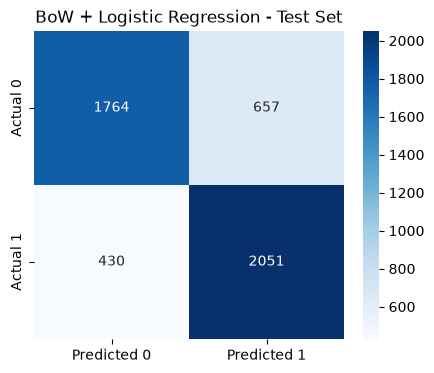

In [69]:
LR_show_result(LR_bow_clf, LR_A_test, LR_y_test, "BoW + Logistic Regression - Test Set")


In [70]:
LR_pos, LR_neg = LR_top_words(LR_bow_final, LR_bow_clf)

print("class 1 (ซึมเศร้า):")
print(", ".join(LR_pos))

print()
print("class 0 (ปกติ):")
print(", ".join(LR_neg))


class 1 (ซึมเศร้า):
ดรีม, คุณหมอ, ยา, โรค, ป่วย, ซึมเศร้า, หมอ, ชั้น, ฆ่าตัวตาย, การรักษา, อาการ, แล่ะ, บล็อก, ค่ะ, ทำร้าย

class 0 (ปกติ):
เธอ, กบ, เติบโต, ดอกไม้, ความรัก, แฮงค์, เมี่ยง, นนท์, เเล้ว, ยาย, พี่, นาย, เรา สอง, บุหรี่, รัฐบาล


## 3. Logistic Regression + TF/IDF

### 3.1 TfidfVectorizer Parameters

In [71]:
def LR_make_tfidf(ngram_range, min_df):
    return TfidfVectorizer(
        tokenizer=LR_identity,
        preprocessor=LR_identity,
        lowercase=False,
        token_pattern=None,
        ngram_range=ngram_range,
        min_df=min_df,
        sublinear_tf=True
    )


print("ใช้ค่าจากหัวข้อ 1.2 -> ngram_range =", LR_NGRAM_RANGE, "| min_df =", LR_MIN_DF)


ใช้ค่าจากหัวข้อ 1.2 -> ngram_range = (1, 2) | min_df = 2


### 3.2 Create Features

In [72]:
LR_tfidf = LR_make_tfidf(LR_NGRAM_RANGE, LR_MIN_DF)

LR_T_train = LR_tfidf.fit_transform(LR_train_tokens)
LR_T_val = LR_tfidf.transform(LR_val_tokens)

print("Vocabulary size:", len(LR_tfidf.vocabulary_))
print("Shape:", LR_T_train.shape)
print()
print("BoW   ค่าตัวอย่าง:", LR_A_train[0].data[:5])
print("TFIDF ค่าตัวอย่าง:", LR_T_train[0].data[:5].round(4))


Vocabulary size: 47578
Shape: (22873, 47578)

BoW   ค่าตัวอย่าง: [1 1 1 1 1]
TFIDF ค่าตัวอย่าง: [0.1274 0.2127 0.2311 0.1232 0.2634]


### 3.3 Hyperparameter Tuning

,C,accuracy,precision,recall,f1,roc_auc
0,0.1,0.7484,0.7426,0.7699,0.7560,0.8288
1,0.3,0.7674,0.7662,0.7779,0.7720,0.8462
2,1.0,0.7802,0.7822,0.7844,0.7833,0.8628
3,3.0,0.7905,0.7934,0.7924,0.7929,0.8698
4,10.0,0.7819,0.7875,0.7795,0.7835,0.8669


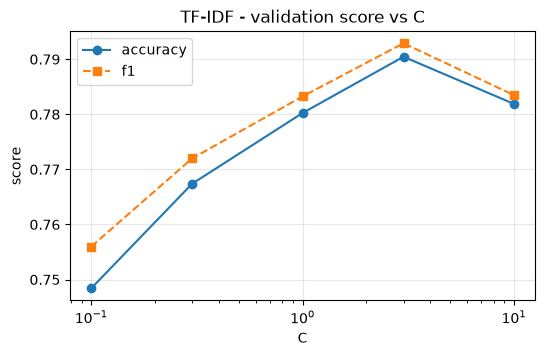

In [73]:
LR_tfidf_tune = LR_tune_C(LR_T_train, LR_y_train, LR_T_val, LR_y_val)

display(LR_tfidf_tune.round(4))
LR_plot_tune(LR_tfidf_tune, "TF-IDF - validation score vs C")


In [74]:
LR_best_C_tfidf = LR_tfidf_tune.loc[LR_tfidf_tune["accuracy"].idxmax(), "C"]

print("Best C (TF-IDF):", LR_best_C_tfidf)
print("Best C (BoW)   :", LR_best_C_bow)


Best C (TF-IDF): 3.0
Best C (BoW)   : 0.3


### 3.4 Train Model

In [75]:
LR_tfidf_final = LR_make_tfidf(LR_NGRAM_RANGE, LR_MIN_DF)

LR_T_full = LR_tfidf_final.fit_transform(LR_full_tokens)
LR_T_test = LR_tfidf_final.transform(LR_test_tokens)

LR_tfidf_clf = LR_train_logreg(LR_T_full, LR_y_full, LR_best_C_tfidf)

print("Trained with C =", LR_best_C_tfidf)
print("Number of features:", LR_tfidf_clf.coef_.shape[1])


Trained with C = 3.0
Number of features: 55860


### 3.5 Evaluation

In [76]:
LR_tfidf_score = LR_evaluate(LR_tfidf_clf, LR_T_test, LR_y_test)

pd.DataFrame([LR_tfidf_score]).round(4)


,accuracy,precision,recall,f1,roc_auc
0,0.7815,0.7831,0.786,0.7846,0.8676


Classification report:
              precision    recall  f1-score   support

           0     0.7799    0.7770    0.7784      2421
           1     0.7831    0.7860    0.7846      2481

    accuracy                         0.7815      4902
   macro avg     0.7815    0.7815    0.7815      4902
weighted avg     0.7815    0.7815    0.7815      4902



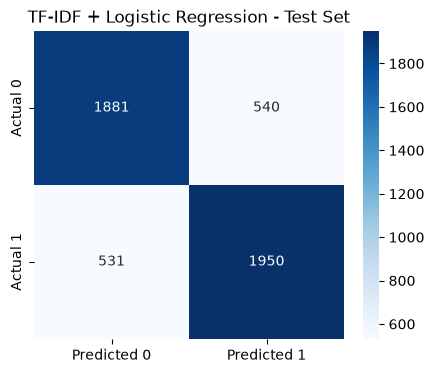

In [77]:
LR_show_result(LR_tfidf_clf, LR_T_test, LR_y_test, "TF-IDF + Logistic Regression - Test Set")


In [78]:
LR_pos, LR_neg = LR_top_words(LR_tfidf_final, LR_tfidf_clf)

print("class 1 (ซึมเศร้า):")
print(", ".join(LR_pos))

print()
print("class 0 (ปกติ):")
print(", ".join(LR_neg))


class 1 (ซึมเศร้า):
ยา, หมอ, เรา, ดรีม, คุณหมอ, โรค, อาการ, ซึมเศร้า, ค่ะ, ป่วย, ชั้น, ฆ่าตัวตาย, การรักษา, ทำร้าย, จิตแพทย์

class 0 (ปกติ):
เธอ, ความรัก, เติบโต, พี่, เขา, กบ, ดอกไม้, นั้น, แฮงค์, รัก, ของ, นาย, ยาย, ครู, เมี่ยง


### 3.6 Compare Bag of Words and TF/IDF

In [79]:
LR_compare = pd.DataFrame([
    {"model": "LR + BoW", **LR_bow_score},
    {"model": "LR + TF-IDF", **LR_tfidf_score}
]).set_index("model")

display(LR_compare.round(4))


,accuracy,precision,recall,f1,roc_auc
model,,,,,
LR + BoW,0.7783,0.7574,0.8267,0.7905,0.8660
LR + TF-IDF,0.7815,0.7831,0.7860,0.7846,0.8676


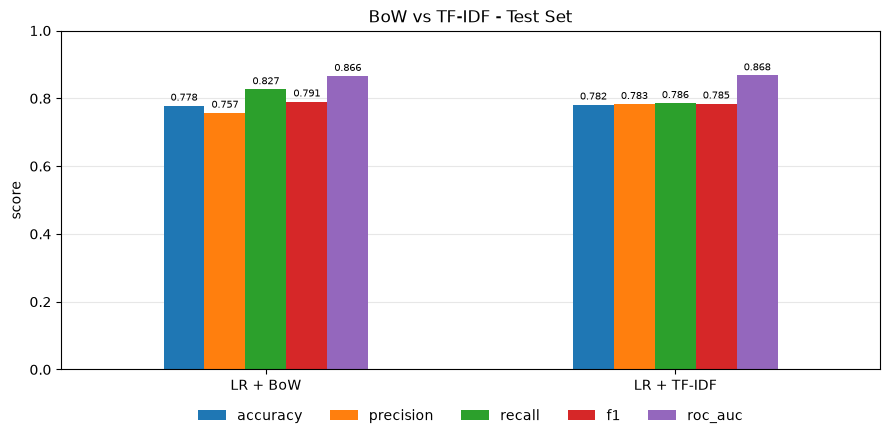

In [80]:
LR_ax = LR_compare.plot.bar(figsize=(9, 4.5), rot=0, zorder=2)

LR_ax.set_title("BoW vs TF-IDF - Test Set")
LR_ax.set_ylabel("score")
LR_ax.set_xlabel("")
LR_ax.set_ylim(0, 1)
LR_ax.grid(axis="y", alpha=0.3, zorder=0)
LR_ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=5, frameon=False)

for LR_container in LR_ax.containers:
    LR_ax.bar_label(LR_container, fmt="%.3f", fontsize=7, padding=2)

plt.tight_layout()
plt.show()


## 4. Decision Tree

### 4.1 Set up

In [101]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

DT_RANDOM_STATE = 42
DT_DEPTH_GRID = [5, 10, 15, 20, 25, 30, 50, None]

def DT_identity(x):
    return x

# ใช้ thai_tokenize และ train_df / val_df / test_df ของส่วนกลาง
DT_train_tokens = train_df["clean_text"].apply(thai_tokenize).tolist()
DT_val_tokens   = val_df["clean_text"].apply(thai_tokenize).tolist()
DT_test_tokens  = test_df["clean_text"].apply(thai_tokenize).tolist()

DT_y_train = train_df["label"].to_numpy()
DT_y_val   = val_df["label"].to_numpy()
DT_y_test  = test_df["label"].to_numpy()

# train + validation รวมกัน ใช้ตอน train model สุดท้าย
DT_full_tokens = DT_train_tokens + DT_val_tokens
DT_y_full = np.concatenate([DT_y_train, DT_y_val])

print("train:", len(DT_train_tokens))
print("val:  ", len(DT_val_tokens))
print("test: ", len(DT_test_tokens))

train: 22873
val:   4901
test:  4902


### 4.2 Decision Tree Helper Functions

In [105]:
def DT_train_tree(X, y, max_depth, min_samples_split=5):
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=DT_RANDOM_STATE
    )
    model.fit(X, y)
    return model

def DT_evaluate(model, X, y):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1] if hasattr(model, "predict_proba") else pred
    return {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
        "roc_auc": roc_auc_score(y, proba)
    }

# จูนค่า max_depth
def DT_tune_depth(X_train, y_train, X_val, y_val):
    rows = []
    for depth in DT_DEPTH_GRID:
        model = DT_train_tree(X_train, y_train, max_depth=depth)
        scores = DT_evaluate(model, X_val, y_val)
        rows.append({
            "max_depth": str(depth),
            "depth_num": depth if depth is not None else 60,
            **scores
        })
    return pd.DataFrame(rows)

def DT_plot_tune(tune_df, title):
    plt.figure(figsize=(7, 3.8))
    plt.plot(tune_df["max_depth"], tune_df["accuracy"], "o-", label="accuracy")
    plt.plot(tune_df["max_depth"], tune_df["f1"], "s--", label="f1")
    plt.plot(tune_df["max_depth"], tune_df["roc_auc"], "^:", label="roc_auc")
    plt.xlabel("max_depth")
    plt.ylabel("score")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def DT_show_result(model, X, y, title):
    pred = model.predict(X)
    
    print("Classification report:")
    print(classification_report(y, pred, digits=4))
    
    cm = confusion_matrix(y, pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted 0", "Predicted 1"],
        yticklabels=["Actual 0", "Actual 1"]
    )
    plt.xlabel("Prediction")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

def DT_top_features(vectorizer, model, top_n=20):
    names = np.array(vectorizer.get_feature_names_out())
    importances = model.feature_importances_
    order = np.argsort(importances)[::-1]
    top_df = pd.DataFrame({
        "feature": names[order[:top_n]],
        "importance": importances[order[:top_n]]
    })
    return top_df

### 4.3 Create Features (TF-IDF)

In [106]:
DT_tfidf = TfidfVectorizer(
    tokenizer=DT_identity,
    preprocessor=DT_identity,
    lowercase=False,
    token_pattern=None,
    ngram_range=LR_NGRAM_RANGE,
    min_df=LR_MIN_DF,
    sublinear_tf=True
)

DT_T_train = DT_tfidf.fit_transform(DT_train_tokens)
DT_T_val   = DT_tfidf.transform(DT_val_tokens)

print("Vocabulary size:", len(DT_tfidf.vocabulary_))
print("Train shape:", DT_T_train.shape)
print("Val shape:  ", DT_T_val.shape)

Vocabulary size: 47578
Train shape: (22873, 47578)
Val shape:   (4901, 47578)


### 4.4 Hyperparameter Tuning (max_depth)

,max_depth,accuracy,precision,recall,f1,roc_auc
0,5,0.6293,0.5857,0.9141,0.7140,0.6869
1,10,0.6621,0.6393,0.7630,0.6957,0.7190
2,15,0.6678,0.6504,0.7432,0.6938,0.7206
3,20,0.6744,0.6517,0.7662,0.7043,0.7153
4,25,0.6766,0.6576,0.7533,0.7022,0.7056
5,30,0.6725,0.6477,0.7743,0.7053,0.6956
6,50,0.6707,0.6468,0.7699,0.7030,0.6815
7,None,0.6609,0.6579,0.6876,0.6724,0.6701


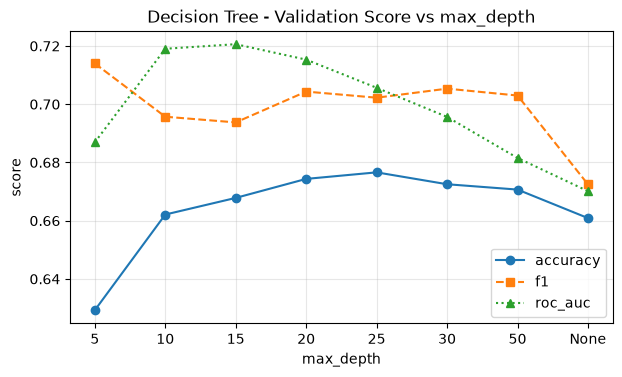

In [107]:
DT_tune_df = DT_tune_depth(DT_T_train, DT_y_train, DT_T_val, DT_y_val)

display(DT_tune_df.drop(columns=["depth_num"]).round(4))
DT_plot_tune(DT_tune_df, "Decision Tree - Validation Score vs max_depth")

In [108]:
DT_best_idx = DT_tune_df["accuracy"].idxmax()
DT_best_depth_str = DT_tune_df.loc[DT_best_idx, "max_depth"]
DT_best_depth = None if DT_best_depth_str == "None" else int(DT_best_depth_str)

print(f"Best max_depth: {DT_best_depth_str} (Validation Accuracy: {DT_tune_df.loc[DT_best_idx, 'accuracy']:.4f})")

Best max_depth: 25 (Validation Accuracy: 0.6766)


### 4.5 Train Final Decision Tree Model

In [109]:
DT_tfidf_final = TfidfVectorizer(
    tokenizer=DT_identity,
    preprocessor=DT_identity,
    lowercase=False,
    token_pattern=None,
    ngram_range=LR_NGRAM_RANGE,
    min_df=LR_MIN_DF,
    sublinear_tf=True
)

DT_T_full = DT_tfidf_final.fit_transform(DT_full_tokens)
DT_T_test = DT_tfidf_final.transform(DT_test_tokens)

DT_clf = DT_train_tree(DT_T_full, DT_y_full, max_depth=DT_best_depth, min_samples_split=5)

print("Trained Decision Tree with max_depth =", DT_best_depth)
print("Tree depth:", DT_clf.get_depth())
print("Number of leaves:", DT_clf.get_n_leaves())

Trained Decision Tree with max_depth = 25
Tree depth: 25
Number of leaves: 899


### 4.6 Evaluation on Test Set

In [110]:
DT_test_score = DT_evaluate(DT_clf, DT_T_test, DT_y_test)

pd.DataFrame([DT_test_score]).round(4)

,accuracy,precision,recall,f1,roc_auc
0,0.6681,0.6482,0.7529,0.6966,0.7124


Classification report:
              precision    recall  f1-score   support

           0     0.6965    0.5812    0.6336      2421
           1     0.6482    0.7529    0.6966      2481

    accuracy                         0.6681      4902
   macro avg     0.6723    0.6670    0.6651      4902
weighted avg     0.6721    0.6681    0.6655      4902



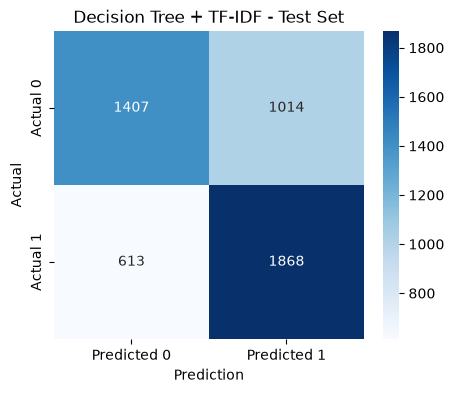

In [111]:
DT_show_result(DT_clf, DT_T_test, DT_y_test, "Decision Tree + TF-IDF - Test Set")

### 4.7 Feature Importance Analysis

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10604\1374231891.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=DT_feat_df, x="importance", y="feature", palette="Blues_r")
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3608 (\N{THAI CHARACTER THO THONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ADMIN\AppData\Local\Packages\PythonSoftwareFoundation.Python.

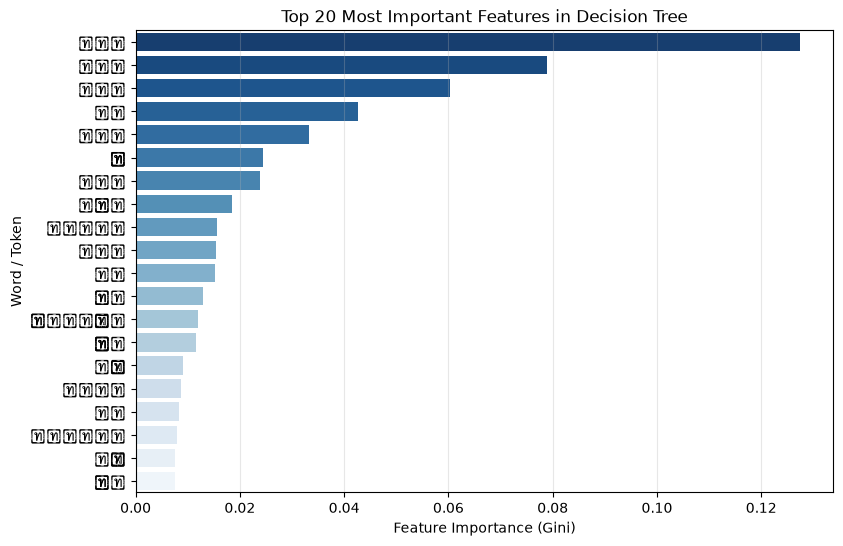

,feature,importance
0,เธอ,0.12741
1,เรา,0.07886
2,ของ,0.06029
3,ยา,0.04270
4,เขา,0.03326
5,ที่,0.02438
6,หมอ,0.02376
7,ดรีม,0.01840
8,อาการ,0.01562
9,โรค,0.01536


In [112]:
DT_feat_df = DT_top_features(DT_tfidf_final, DT_clf, top_n=20)

plt.figure(figsize=(9, 6))
sns.barplot(data=DT_feat_df, x="importance", y="feature", palette="Blues_r")
plt.title("Top 20 Most Important Features in Decision Tree")
plt.xlabel("Feature Importance (Gini)")
plt.ylabel("Word / Token")
plt.grid(axis="x", alpha=0.3)
plt.show()

display(DT_feat_df.round(5))

## 5. Overall Model Comparison

In [113]:
all_compare = pd.DataFrame([
    {
        "model": "BiLSTM + Word2Vec",
        "accuracy": accuracy_score(BIMD_y_test, BIMD_test_pred),
        "precision": precision_score(BIMD_y_test, BIMD_test_pred),
        "recall": recall_score(BIMD_y_test, BIMD_test_pred),
        "f1": f1_score(BIMD_y_test, BIMD_test_pred),
        "roc_auc": roc_auc_score(BIMD_y_test, BIMD_test_prob)
    },
    {"model": "LR + BoW", **LR_bow_score},
    {"model": "LR + TF-IDF", **LR_tfidf_score},
    {"model": "Decision Tree + TF-IDF", **DT_test_score}
]).set_index("model")

display(all_compare.round(4))

,accuracy,precision,recall,f1,roc_auc
model,,,,,
BiLSTM + Word2Vec,0.7840,0.7505,0.8585,0.8009,0.8715
LR + BoW,0.7783,0.7574,0.8267,0.7905,0.8660
LR + TF-IDF,0.7815,0.7831,0.7860,0.7846,0.8676
Decision Tree + TF-IDF,0.6681,0.6482,0.7529,0.6966,0.7124


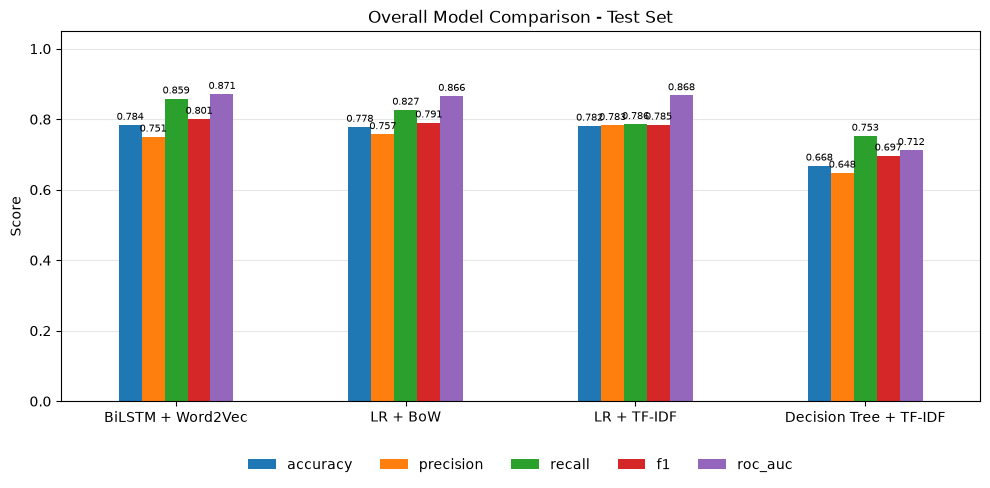

In [114]:
ax = all_compare.plot.bar(figsize=(10, 5), rot=0, zorder=2)
ax.set_title("Overall Model Comparison - Test Set")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5, frameon=False)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)

plt.tight_layout()
plt.show()